In [1]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

In [2]:
print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv(r"C:\Users\hp\OneDrive\Desktop\studentsdata\StudentPerformanceFactors.csv")

In [4]:
print(df.head())

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

In [5]:
df = pd.read_csv(r"C:\Users\hp\OneDrive\Desktop\studentsdata\StudentPerformanceFactors.csv")

In [6]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder

df = pd.read_csv(r"C:\Users\hp\OneDrive\Desktop\studentsdata\StudentPerformanceFactors.csv")

df_arm = df.dropna().copy()


num_cols = df_arm.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    
   
    df_arm[col] = pd.qcut(df_arm[col], q=3, duplicates='drop').astype(str)

transactions = []
for index, row in df_arm.iterrows():
    student_traits = [f"{col}_{str(val)}" for col, val in row.items()]
    transactions.append(student_traits)

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)


df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print("--- Prepared Apriori Data (First 5 Rows) ---")
print(df_encoded.head())

--- Prepared Apriori Data (First 5 Rows) ---
   Access_to_Resources_High  Access_to_Resources_Low  \
0                      True                    False   
1                     False                    False   
2                     False                    False   
3                     False                    False   
4                     False                    False   

   Access_to_Resources_Medium  Attendance_(59.999, 73.0]  \
0                       False                      False   
1                        True                       True   
2                        True                      False   
3                        True                      False   
4                        True                      False   

   Attendance_(73.0, 87.0]  Attendance_(87.0, 100.0]  Distance_from_Home_Far  \
0                     True                     False                   False   
1                    False                     False                   False   
2                

In [7]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori

# Load data
df = pd.read_csv(r"C:\Users\hp\OneDrive\Desktop\studentsdata\StudentPerformanceFactors.csv")
df_arm = df.dropna().copy()

num_cols = df_arm.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    df_arm[col] = pd.qcut(df_arm[col], q=3, duplicates='drop').astype(str)

transactions = []
for index, row in df_arm.iterrows():
    student_traits = [f"{col}_{str(val)}" for col, val in row.items()]
    transactions.append(student_traits)
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = apriori(df_encoded, min_support=0.2, use_colnames=True, max_len=3)
frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)

print("--- Frequent Itemsets (Top 5) ---")
print(frequent_itemsets.head(5))

--- Frequent Itemsets (Top 5) ---
      support                                           itemsets
19   0.923957                   frozenset({Internet_Access_Yes})
20   0.895265              frozenset({Learning_Disabilities_No})
221  0.826748  frozenset({Internet_Access_Yes, Learning_Disab...
33   0.700220       frozenset({Physical_Activity_(-0.001, 3.0]})
39   0.695202                    frozenset({School_Type_Public})


In [8]:
from mlxtend.frequent_patterns import association_rules

# 1. Generate rules using the frequent itemsets from Step 4
# We only keep rules where the confidence is at least 30% (0.3)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)

# 2. Sort the rules by 'lift' (how strongly the two traits are connected)
rules = rules.sort_values(by='lift', ascending=False)

# 3. Print the top 5 most interesting rules
print("--- Top 5 Association Rules ---")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5))

--- Top 5 Association Rules ---
                                            antecedents  \
1603             frozenset({Attendance_(59.999, 73.0]})   
1599  frozenset({Exam_Score_(54.999, 66.0], Learning...   
1431  frozenset({Exam_Score_(54.999, 66.0], Internet...   
1435             frozenset({Attendance_(59.999, 73.0]})   
1064             frozenset({Attendance_(59.999, 73.0]})   

                                            consequents   support  confidence  \
1603  frozenset({Exam_Score_(54.999, 66.0], Learning...  0.231734    0.690332   
1599             frozenset({Attendance_(59.999, 73.0]})  0.231734    0.613533   
1431             frozenset({Attendance_(59.999, 73.0]})  0.241141    0.612505   
1435  frozenset({Exam_Score_(54.999, 66.0], Internet...  0.241141    0.718356   
1064             frozenset({Exam_Score_(54.999, 66.0]})  0.263092    0.783746   

          lift  
1603  1.827702  
1599  1.827702  
1431  1.824641  
1435  1.824641  
1064  1.805900  


C:\Users\hp\AppData\Local\Temp\ipykernel_6676\72381956.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=item_frequencies.head(10).values,


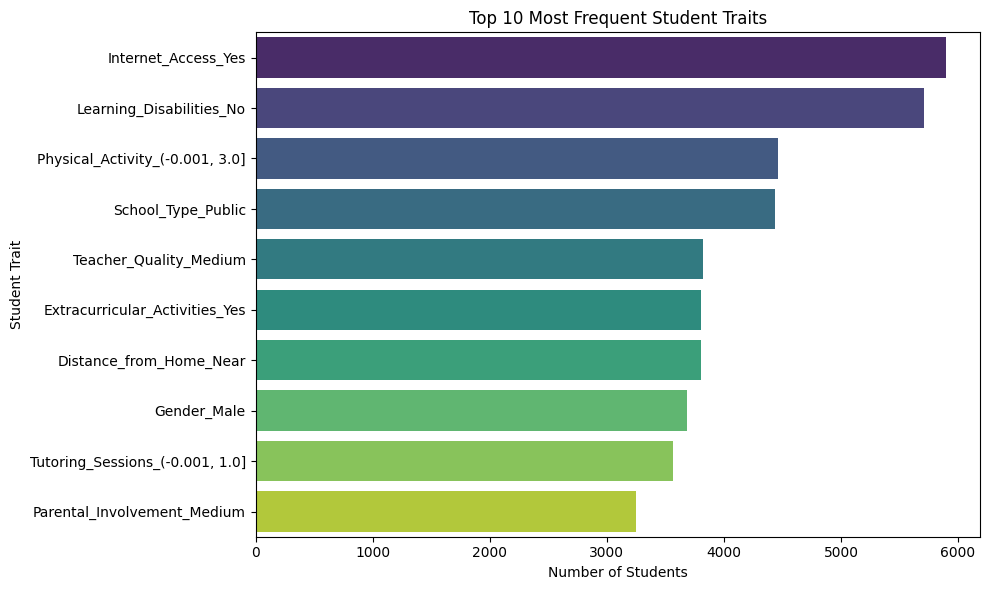

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

item_frequencies = df_encoded.sum().sort_values(ascending=False)


plt.figure(figsize=(10, 6))
sns.barplot(x=item_frequencies.head(10).values, 
            y=item_frequencies.head(10).index, 
            palette='viridis') 
plt.title('Top 10 Most Frequent Student Traits')
plt.xlabel('Number of Students')
plt.ylabel('Student Trait')

plt.tight_layout()
plt.show()

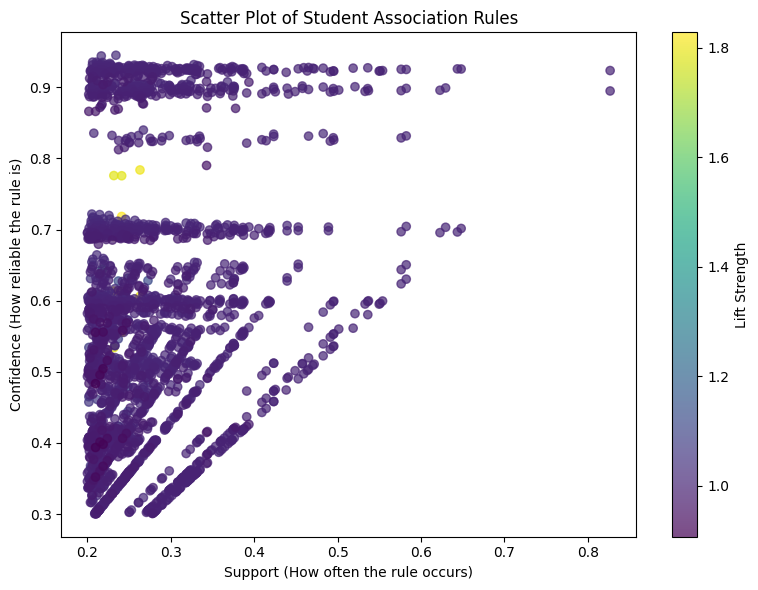

In [10]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 6))


scatter = plt.scatter(rules['support'], rules['confidence'], 
                      c=rules['lift'], cmap='viridis', alpha=0.7)

plt.colorbar(scatter, label='Lift Strength')

plt.xlabel('Support (How often the rule occurs)')
plt.ylabel('Confidence (How reliable the rule is)')
plt.title('Scatter Plot of Student Association Rules')

plt.tight_layout()
plt.show()

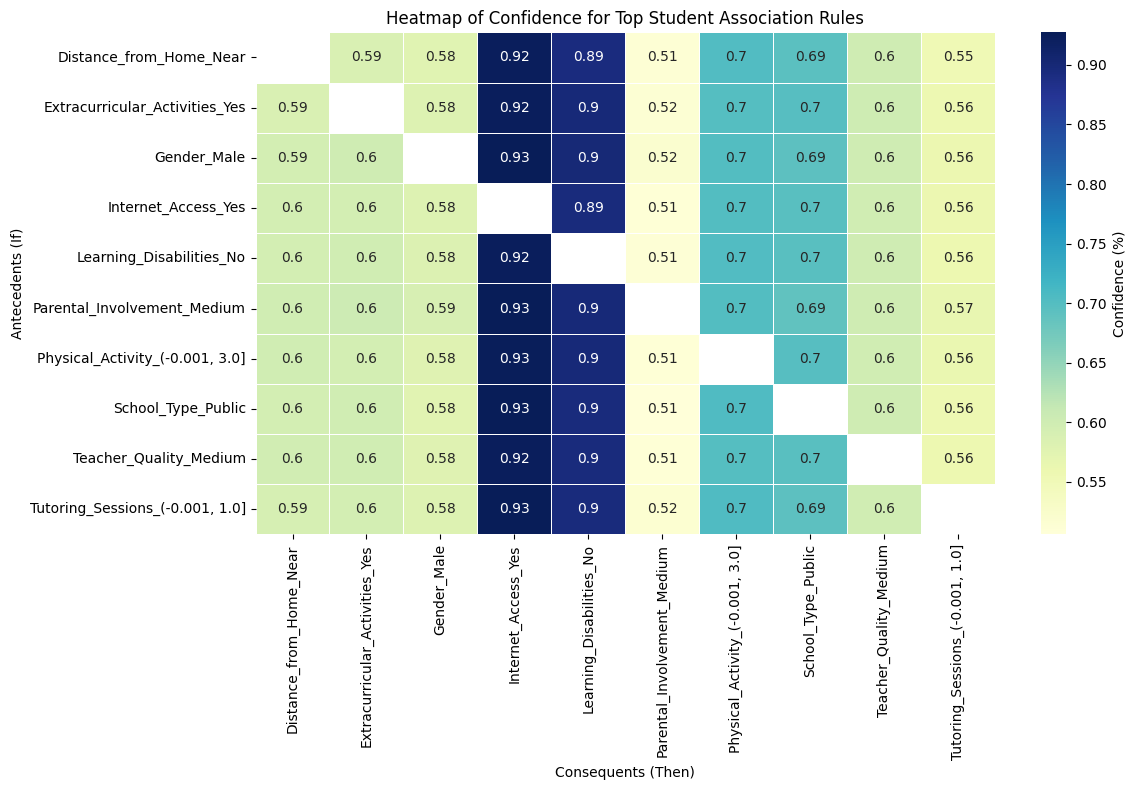

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

top_ants = rules.groupby('antecedents_str')['support'].sum().nlargest(10).index
top_cons = rules.groupby('consequents_str')['support'].sum().nlargest(10).index


filtered = rules[(rules['antecedents_str'].isin(top_ants)) & 
                 (rules['consequents_str'].isin(top_cons))]

heatmap_data = filtered.pivot_table(
    index='antecedents_str', 
    columns='consequents_str', 
    values='confidence',
    aggfunc='max' 
)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', 
            linewidths=0.5, cbar_kws={'label': 'Confidence (%)'})

plt.title('Heatmap of Confidence for Top Student Association Rules')
plt.xlabel('Consequents (Then)')
plt.ylabel('Antecedents (If)')

plt.tight_layout()
plt.show()